# COVID-19 Symptoms Prediction using Machine Learning

This notebook demonstrates the process of building a machine learning model to predict COVID-19 infection probability based on symptoms. It covers data loading, preprocessing, model training, and evaluation.

Dataset loaded successfully.
   fever  bodyPain  age  runnyNose  diffBreath  infectionProb
0    102         0    9          0          -1              0
1    102         0   10          0           0              1
2    104         0   33          1          -1              0
3    101         1   59          0           1              0
4     99         0   98          0           0              0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2575 entries, 0 to 2574
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   fever          2575 non-null   int64
 1   bodyPain       2575 non-null   int64
 2   age            2575 non-null   int64
 3   runnyNose      2575 non-null   int64
 4   diffBreath     2575 non-null   int64
 5   infectionProb  2575 non-null   int64
dtypes: int64(6)
memory usage: 120.8 KB

Summary Statistics:
             fever     bodyPain          age    runnyNose   diffBreath  \
count  

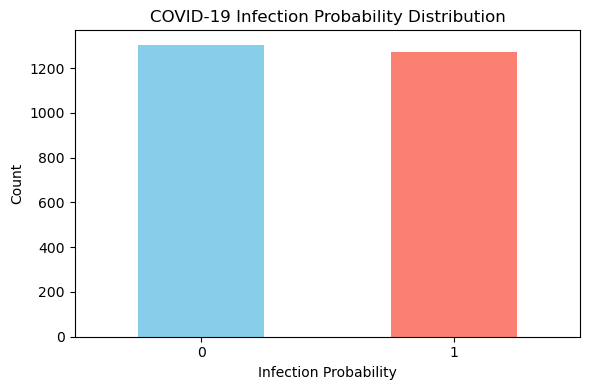

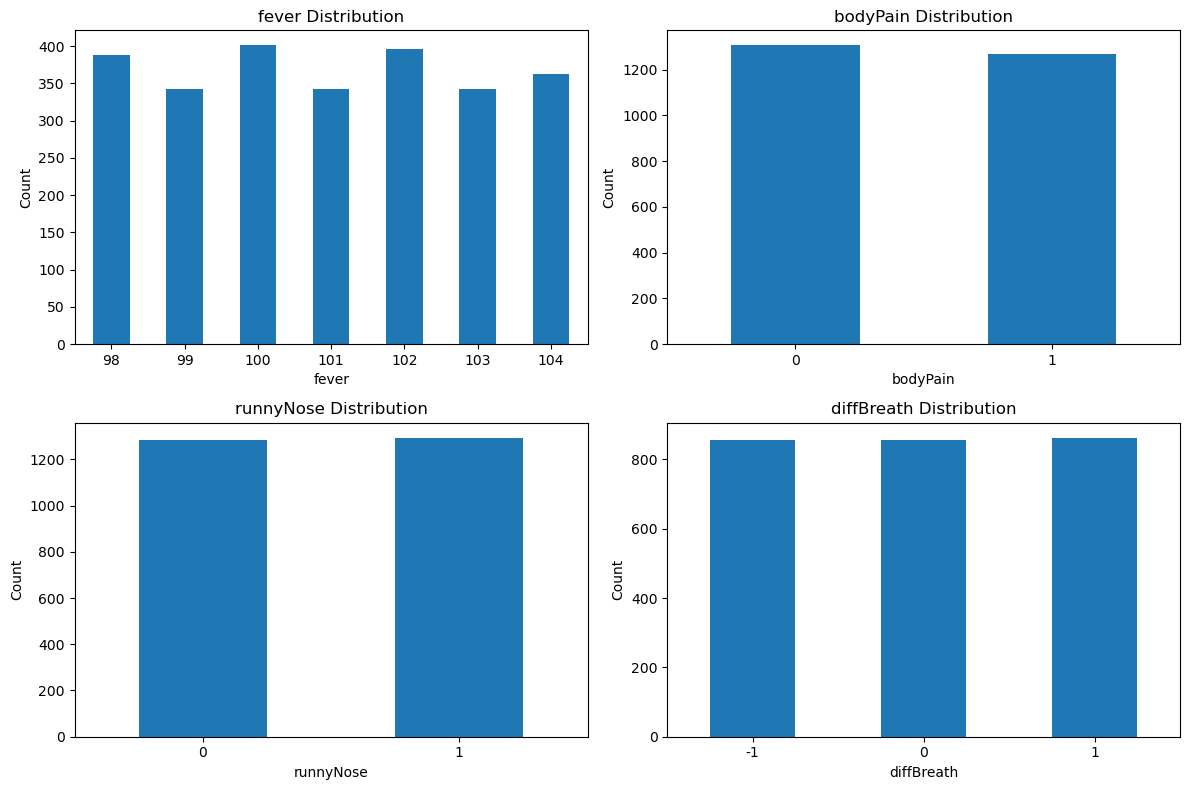

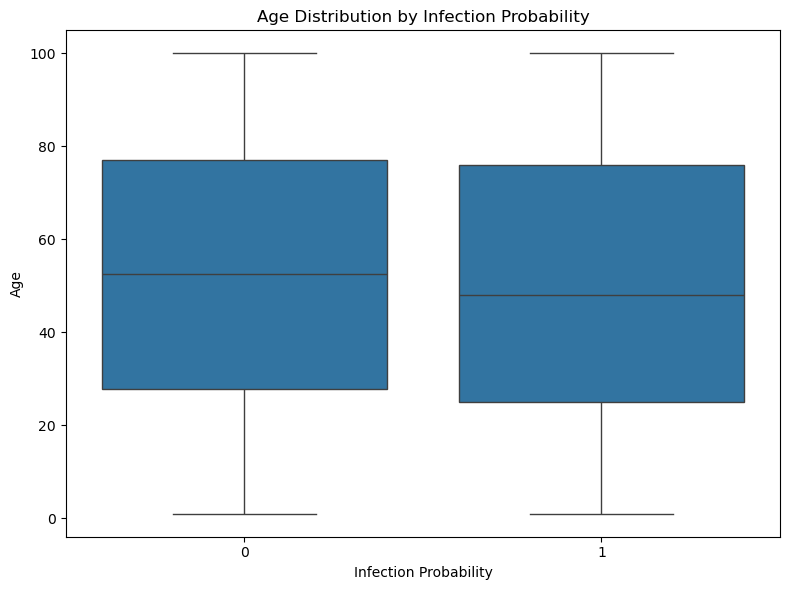

Starting tabular data preprocessing...
Tabular data preprocessing complete.

Preprocessed feature shape: (2575, 9)
      fever       age  bodyPain_0  bodyPain_1  runnyNose_0  runnyNose_1  \
0  0.515305 -1.448639         1.0         0.0          1.0          0.0   
1  0.515305 -1.414167         1.0         0.0          1.0          0.0   
2  1.515614 -0.621304         1.0         0.0          0.0          1.0   
3  0.015150  0.274975         0.0         1.0          1.0          0.0   
4 -0.985159  1.619394         1.0         0.0          1.0          0.0   

   diffBreath_-1  diffBreath_0  diffBreath_1  
0            1.0           0.0           0.0  
1            0.0           1.0           0.0  
2            1.0           0.0           0.0  
3            0.0           0.0           1.0  
4            0.0           1.0           0.0  
Train shape: (2060, 9), Test shape: (515, 9)

Training Random Forest...
Training complete.

Evaluation Metrics:
Accuracy: 0.5534
Precision: 0.5469
Recal

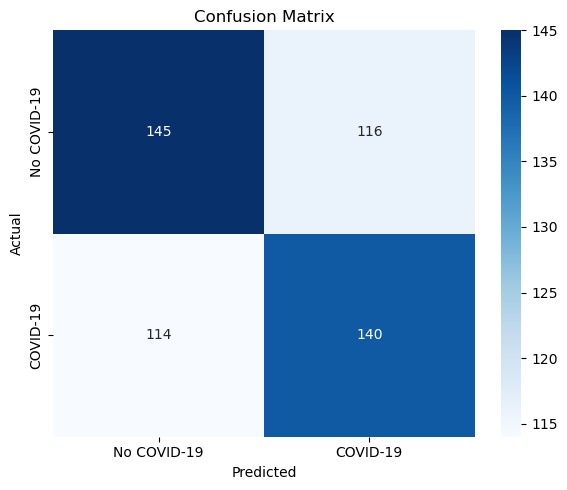

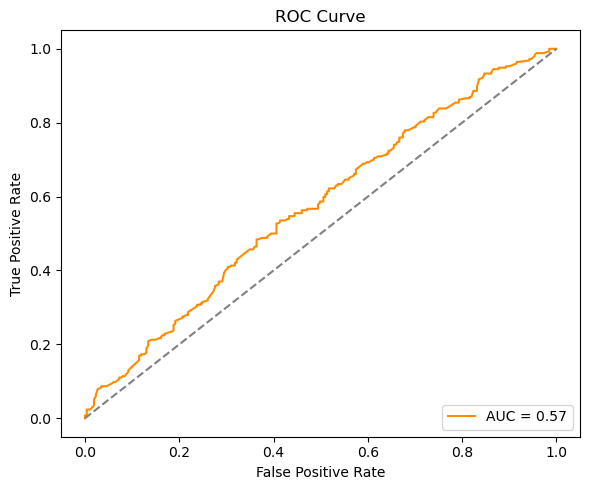

/tmp/ipykernel_158504/2513349863.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x="importance", y="feature", palette="viridis")


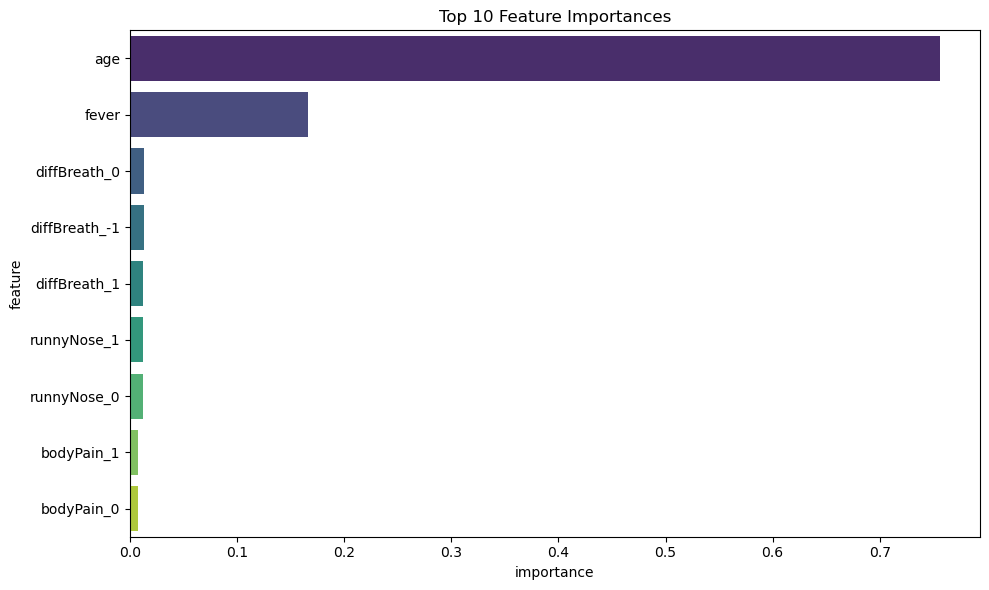


Top 10 Features:
         feature  importance
1            age    0.755734
0          fever    0.166646
7   diffBreath_0    0.012849
6  diffBreath_-1    0.012729
8   diffBreath_1    0.012595
5    runnyNose_1    0.012511
4    runnyNose_0    0.011973
3     bodyPain_1    0.007531
2     bodyPain_0    0.007432
Model and preprocessor saved.


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import joblib

# Import data_preprocessing utility
sys.path.append(os.path.abspath('../'))
from src.utils.data_preprocessing import preprocess_tabular_data

# --- 1. Data Loading ---
data_path = "../data/raw/covid19_symptoms/covid-19 symptoms dataset.csv"

try:
    data = pd.read_csv(data_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: {data_path} not found. Creating dummy data for demonstration.")
    np.random.seed(42)
    data = pd.DataFrame({
        "fever": np.random.randint(98, 105, 1000),
        "bodyPain": np.random.choice([0, 1], 1000),
        "age": np.random.randint(1, 100, 1000),
        "runnyNose": np.random.choice([0, 1], 1000),
        "diffBreath": np.random.choice([-1, 0, 1], 1000),
        "infectionProb": np.random.choice([0, 1], 1000)
    })

print(data.head())

# --- 2. EDA ---
print("\nDataset Info:")
data.info()

print("\nSummary Statistics:")
print(data.describe(include="all"))

print("\nMissing Values:")
print(data.isnull().sum())

# Target distribution
plt.figure(figsize=(6, 4))
data["infectionProb"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("COVID-19 Infection Probability Distribution")
plt.xlabel("Infection Probability")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Symptom distribution
symptom_cols = ["fever", "bodyPain", "runnyNose", "diffBreath"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, symptom in enumerate(symptom_cols):
    data[symptom].value_counts().sort_index().plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{symptom} Distribution")
    axes[i].set_xlabel(symptom)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

# Age distribution by infection
plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="infectionProb", y="age")
plt.title("Age Distribution by Infection Probability")
plt.xlabel("Infection Probability")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

# --- 3. Data Preprocessing ---
numerical_cols = ["fever", "age"]
categorical_cols = ["bodyPain", "runnyNose", "diffBreath"]
target_column = "infectionProb"

X_processed, y, preprocessor = preprocess_tabular_data(data, numerical_cols, categorical_cols, target_column)

print("\nPreprocessed feature shape:", X_processed.shape)
print(X_processed.head())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# --- 4. Model Building ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining Random Forest...")
model.fit(X_train, y_train)
print("Training complete.")

# --- 5. Evaluation ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No COVID-19", "COVID-19"],
            yticklabels=["No COVID-19", "COVID-19"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.DataFrame({
    "feature": X_processed.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importances.head(10))

# --- 6. Save Model ---
joblib.dump(model, "covid19_symptoms_random_forest_model.pkl")
joblib.dump(preprocessor, "covid19_symptoms_preprocessor.pkl")
print("Model and preprocessor saved.")
